Importing the dependencies

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
import keras

Data Collection and Pre-Processing

In [6]:
# loading the data from the csv file to apandas dataframe
df=pd.read_csv('/content/Airline_Delay_Cause.csv')

In [ ]:
# printing the first 5 rows of the dataframe
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",136.0,7.0,5.95,0.00,...,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",91.0,16.0,7.38,0.00,...,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,9E,Endeavor Air Inc.,ACK,"Nantucket, MA: Nantucket Memorial",19.0,2.0,0.13,0.00,...,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",88.0,14.0,7.26,0.76,...,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",181.0,19.0,13.84,0.00,...,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0


In [7]:
# printing the last 5 rows of the dataframe
df.tail()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
318012,2003,6,DL,Delta Air Lines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",480.0,84.0,25.69,3.09,...,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
318013,2003,6,DL,Delta Air Lines Inc.,SFO,"San Francisco, CA: San Francisco International",505.0,111.0,21.78,2.24,...,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
318014,2003,6,DL,Delta Air Lines Inc.,SJC,"San Jose, CA: Norman Y. Mineta San Jose Intern...",146.0,36.0,6.99,0.00,...,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
318015,2003,6,DL,Delta Air Lines Inc.,SJU,"San Juan, PR: Luis Munoz Marin International",95.0,13.0,3.66,0.00,...,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0
318016,2003,6,DL,Delta Air Lines Inc.,SLC,"Salt Lake City, UT: Salt Lake City International",3466.0,454.0,121.15,7.61,...,1.0,102.33,9.0,0.0,16853.0,5384.0,306.0,5686.0,28.0,5449.0


In [8]:
# number of rows and columns in the data frame
df.shape

(318017, 21)

In [9]:
# getting more information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 318017 entries, 0 to 318016
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 318017 non-null  int64  
 1   month                318017 non-null  int64  
 2   carrier              318013 non-null  object 
 3   carrier_name         318013 non-null  object 
 4   airport              318014 non-null  object 
 5   airport_name         318017 non-null  object 
 6   arr_flights          317524 non-null  float64
 7   arr_del15            317285 non-null  float64
 8   carrier_ct           317525 non-null  float64
 9   weather_ct           317523 non-null  float64
 10  nas_ct               317529 non-null  float64
 11  security_ct          317529 non-null  float64
 12  late_aircraft_ct     317529 non-null  float64
 13  arr_cancelled        317529 non-null  float64
 14  arr_diverted         317527 non-null  float64
 15  arr_delay        

In [10]:
# checking for missing values in each column
df.isnull().sum()

,0
year,0
month,0
carrier,4
carrier_name,4
airport,3
airport_name,0
arr_flights,493
arr_del15,732
carrier_ct,492
weather_ct,494


In [11]:
# Dropping unnecessary columns: 'carrier', 'carrier_name', 'airport', and 'airport_name' from the DataFrame
df = df.drop(['carrier','carrier_name','airport','airport_name'],axis=1)
df

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2022,5,136.0,7.0,5.95,0.00,0.05,0.0,1.00,0.0,0.0,255.0,222.0,0.0,4.0,0.0,29.0
1,2022,5,91.0,16.0,7.38,0.00,2.54,0.0,6.09,0.0,0.0,884.0,351.0,0.0,81.0,0.0,452.0
2,2022,5,19.0,2.0,0.13,0.00,1.00,0.0,0.88,1.0,0.0,138.0,4.0,0.0,106.0,0.0,28.0
3,2022,5,88.0,14.0,7.26,0.76,4.35,0.0,1.64,0.0,0.0,947.0,585.0,35.0,125.0,0.0,202.0
4,2022,5,181.0,19.0,13.84,0.00,3.07,0.0,2.09,0.0,0.0,808.0,662.0,0.0,87.0,0.0,59.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
318012,2003,6,480.0,84.0,25.69,3.09,33.96,0.0,21.26,0.0,0.0,3744.0,978.0,164.0,1023.0,0.0,1579.0
318013,2003,6,505.0,111.0,21.78,2.24,73.81,0.0,13.17,3.0,0.0,4284.0,1376.0,138.0,2132.0,0.0,638.0
318014,2003,6,146.0,36.0,6.99,0.00,26.85,0.0,2.15,0.0,0.0,896.0,205.0,0.0,607.0,0.0,84.0
318015,2003,6,95.0,13.0,3.66,0.00,7.92,0.0,1.42,0.0,0.0,367.0,120.0,0.0,210.0,0.0,37.0


In [12]:
# Dropping all rows with missing values from the DataFrame
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

,0
year,0
month,0
arr_flights,0
arr_del15,0
carrier_ct,0
weather_ct,0
nas_ct,0
security_ct,0
late_aircraft_ct,0
arr_cancelled,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 317268 entries, 0 to 318016
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 317268 non-null  int64  
 1   month                317268 non-null  int64  
 2   arr_flights          317268 non-null  float64
 3   arr_del15            317268 non-null  float64
 4   carrier_ct           317268 non-null  float64
 5   weather_ct           317268 non-null  float64
 6   nas_ct               317268 non-null  float64
 7   security_ct          317268 non-null  float64
 8   late_aircraft_ct     317268 non-null  float64
 9   arr_cancelled        317268 non-null  float64
 10  arr_diverted         317268 non-null  float64
 11  arr_delay            317268 non-null  float64
 12  carrier_delay        317268 non-null  float64
 13  weather_delay        317268 non-null  float64
 14  nas_delay            317268 non-null  float64
 15  security_delay       3


Multi-class Target

In [15]:
# دالة لتقسيم التأخير إلى 3 فئات
def categorize_delay(delay):
    if delay <= 100:
        return 0
    elif delay <= 500:
        return 1
    else:
        return 2

df['Delay_Class'] = df['arr_delay'].apply(categorize_delay)

# عرض توزيع الفئات
print("توزيع الفئات في البيانات:")
print(df['Delay_Class'].value_counts())

توزيع الفئات في البيانات:
Delay_Class
2    229264
1     62356
0     25648
Name: count, dtype: int64


Data Pre-Processing

Separating the features & Target

In [28]:
# تحديد كل الأعمدة التي تسبب تسرب البيانات (Data Leakage)
leaky_columns = [
    'Delay_Class', 'arr_delay',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay',
    'arr_del15', 'arr_cancelled', 'arr_diverted',
    'carrier_ct', 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct'
]

# فصل الميزات (X) عن الهدف (y) بعد حذف الأعمدة التي تغشش الموديل
X = df.drop(columns=leaky_columns, errors='ignore').values
y = df['Delay_Class'].values

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle=True)

# توحيد مقياس البيانات (Standardization)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)

X_train shape: (237951, 3)
y_train shape: (237951,)


In [29]:
# بناء الموديل مع تحديد 3 مخرجات في الطبقة الأخيرة (للتصنيف المتعدد)
KerasModel = keras.models.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.2), # لمنع الحفظ الأعمى (Overfitting)
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax') # 3 فئات باستخدام softmax
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
# تعريف المُحسّن الخاص بك (AdamW)
MyOptimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.001,
    weight_decay=0.004,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07,
    amsgrad=False,
    name="AdamW"
)

# عمل Compile للموديل باستخدام sparse_categorical_crossentropy (مهم جداً)
KerasModel.compile(
    optimizer=MyOptimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
# Compile the Keras model with the specified optimizer, loss function, and evaluation metric
KerasModel.compile(optimizer=MyOptimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [32]:
# تدريب الموديل
history = KerasModel.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=512, # تم تكبير الحجم لتسريع التدريب
    verbose=1,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)]
)

Epoch 1/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7520 - loss: 0.5883 - val_accuracy: 0.8066 - val_loss: 0.4462
Epoch 2/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8045 - loss: 0.4479 - val_accuracy: 0.8107 - val_loss: 0.4348
Epoch 3/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8076 - loss: 0.4414 - val_accuracy: 0.8111 - val_loss: 0.4329
Epoch 4/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8096 - loss: 0.4374 - val_accuracy: 0.8129 - val_loss: 0.4281
Epoch 5/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8105 - loss: 0.4337 - val_accuracy: 0.8142 - val_loss: 0.4258
Epoch 6/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8113 - loss: 0.4325 - val_accuracy: 0.8147 - val_loss: 0.4231
Epoch 7/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8117 - loss: 0.4296 - val_accuracy: 0.8136 - val_loss: 0.4222
Epoch 8/50
465/465 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8131 - loss: 0.4265 - val_accuracy: 0.

In [33]:
print(KerasModel.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,747 (34.17 KB)

 Trainable params: 2,915 (11.39 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,832 (22.79 KB)

None


In [34]:
# Use the trained model to predict labels for the test data (X_test)
y_pred=KerasModel.predict(X_test)

2479/2479 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step


In [35]:
print('Prediction Shape is {}'.format(y_pred.shape))

Prediction Shape is (79317, 3)


In [36]:
print('Prediction items are {}'.format(y_pred[:5]))

Prediction items are [[4.4645840e-05 9.7444225e-03 9.9021095e-01]
 [3.0559725e-06 2.3772332e-03 9.9761969e-01]
 [7.6648928e-02 5.5216163e-01 3.7118950e-01]
 [2.7508415e-02 3.6763909e-01 6.0485256e-01]
 [1.8782705e-02 1.8452473e-01 7.9669261e-01]]


In [37]:
# Evaluate the model's performance on the test data
ModelLoss, ModelAccuracy = KerasModel.evaluate(X_test, y_test)

# Print the loss (error) of the model
print('Model Loss is {}'.format(ModelLoss))

# Print the accuracy of the model
print('Model Accuracy is {}'.format(ModelAccuracy))


2479/2479 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8224 - loss: 0.4037
Model Loss is 0.4036880433559418
Model Accuracy is 0.8224214315414429


2479/2479 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8224 - loss: 0.4037
Model Loss is 0.4036880433559418
Model Accuracy is 0.8224214315414429


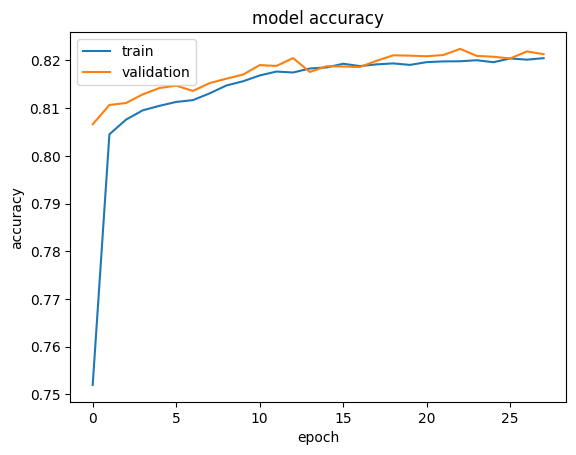

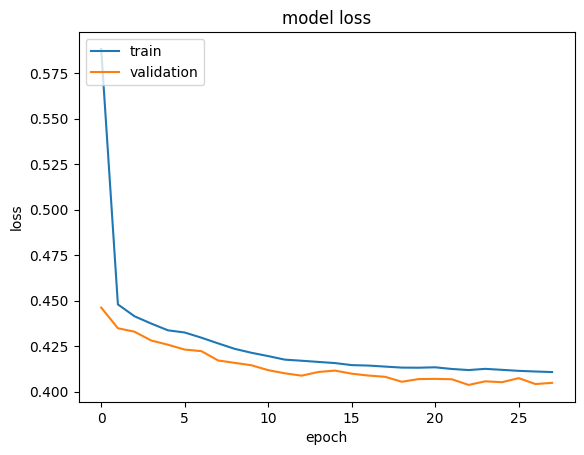

2479/2479 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Confusion Matrix is : 
 [[ 3350  2683   350]
 [  947  8278  6500]
 [   59  3546 53604]]


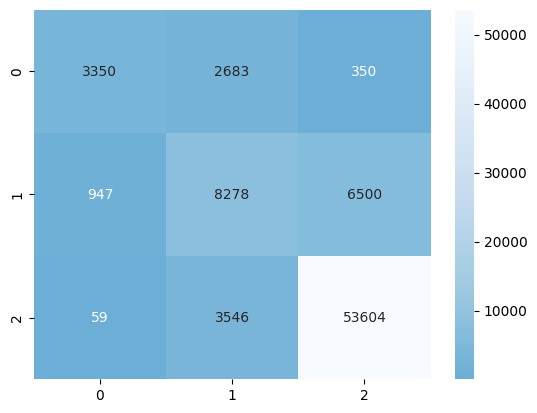

Classification Report is : 
               precision    recall  f1-score   support

           0       0.77      0.52      0.62      6383
           1       0.57      0.53      0.55     15725
           2       0.89      0.94      0.91     57209

    accuracy                           0.82     79317
   macro avg       0.74      0.66      0.69     79317
weighted avg       0.81      0.82      0.82     79317



In [38]:
# 1. تقييم أداء الموديل على بيانات الاختبار
ModelLoss, ModelAccuracy = KerasModel.evaluate(X_test, y_test)

print('Model Loss is {}'.format(ModelLoss))
print('Model Accuracy is {}'.format(ModelAccuracy))

# 2. رسم منحنى الدقة (Accuracy)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# 3. رسم منحنى الخسارة (Loss)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

# 4. استخراج التنبؤات للتصنيف المتعدد
y_pred_probs = KerasModel.predict(X_test)
# 🚨 هنا التعديل الأهم: استخدام argmax بدلاً من round
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 5. حساب ورسم مصفوفة الارتباك (Confusion Matrix)
CM = confusion_matrix(y_test, y_pred_classes)
print('Confusion Matrix is : \n', CM)

# إضافة annot=True و fmt='d' لتظهر الأرقام بوضوح داخل المربعات
sns.heatmap(CM, center=True, cmap='Blues_r', annot=True, fmt='d')
plt.show()

# 6. طباعة تقرير التصنيف النهائي
ClassificationReport = classification_report(y_test, y_pred_classes)
print('Classification Report is : \n', ClassificationReport)

2479/2479 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
Model Accuracy: 82.24%



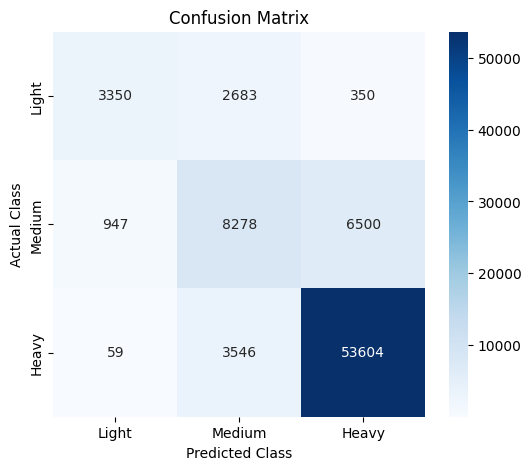


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.52      0.62      6383
           1       0.57      0.53      0.55     15725
           2       0.89      0.94      0.91     57209

    accuracy                           0.82     79317
   macro avg       0.74      0.66      0.69     79317
weighted avg       0.81      0.82      0.82     79317



In [39]:
# التنبؤ بالبيانات الاختبارية
y_pred_probs = KerasModel.predict(X_test)
# أخذ الفئة ذات الاحتمالية الأعلى
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# تقييم الأداء العام
ModelLoss, ModelAccuracy = KerasModel.evaluate(X_test, y_test, verbose=0)
print(f'Model Accuracy: {ModelAccuracy * 100:.2f}%\n')

# مصفوفة الارتباك
CM = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(CM, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Light', 'Medium', 'Heavy'],
            yticklabels=['Light', 'Medium', 'Heavy'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.show()

# تقرير التصنيف
print('\nClassification Report:\n', classification_report(y_test, y_pred_classes))